In [39]:
import os
from dotenv import load_dotenv
load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("bro it is working")


from langchain.chat_models import init_chat_model

llm_model = init_chat_model(model="gpt-5-nano")

bro it is working


In [40]:
from pydantic import BaseModel, Field
from typing import Literal

class llm_schema(BaseModel):
    sentiment: Literal["positive","negative"] = Field(description="calssification values for movie review")

In [41]:
llm_with_StrcuturedOutput = llm_model.with_structured_output(llm_schema)
# result = llm_with_StrcuturedOutput.invoke("KGF IS THE BEST MOVIE")
# print(result)

In [42]:
from typing import TypedDict, List
class graph_schema(TypedDict):
    movieName: str
    movieReview: str
    movieSentiment: str
    moviePost: str

In [43]:
def movieReview_node(schema: graph_schema):

    movieName = schema["movieName"]
    llm_response = llm_model.invoke(f"Give the small review of the this movie, name is {movieName}").content
    return {"movieReview" : llm_response}

In [44]:
def movieSentiment_node(schema: graph_schema):

    movieReview = schema["movieReview"]
    response = llm_with_StrcuturedOutput.invoke(f"Classify the overall sentiment of this movie review as postive or negative {movieReview}")
    return { "movieSentiment": response.sentiment}

In [45]:
def create_post_insta_node(schema:graph_schema):

    movieReview = schema["movieReview"]
    Llm_Response = llm_model.invoke(f"Generate a short “why this movie is bad ” recommendation post for Instagram based on this review {movieReview}").content
    return {"moviePost": Llm_Response}

def create_post_linkedIn_node(schema:graph_schema):

    movieReview = schema["movieReview"]
    Llm_Response = llm_model.invoke(f"Generate a short “Why you should watch this movie” recommendation post for linkedIn based on this review {movieReview}").content
    return {"moviePost": Llm_Response}

In [46]:
def decider_condtion(schema: graph_schema):

    movieSentiment = schema["movieSentiment"]

    if movieSentiment == "positive":
        return "create_post_linkedIn_node"
    else:
        return "create_post_insta_node"

In [47]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("movieReview_node",movieReview_node)
graph.add_node("movieSentiment_node",movieSentiment_node)
#graph.add_node("decider_condtion", decider_condtion)
graph.add_node("create_post_insta_node", create_post_insta_node)
graph.add_node("create_post_linkedIn_node", create_post_linkedIn_node)

graph.add_edge(START, "movieReview_node")
graph.add_edge("movieReview_node", "movieSentiment_node")

graph.add_conditional_edges(
    "movieSentiment_node", 
    decider_condtion, 
    {
    "create_post_linkedIn_node" :"create_post_linkedIn_node",
    "create_post_insta_node": "create_post_insta_node"
},
)

graph.add_edge("create_post_linkedIn_node", END)
graph.add_edge("create_post_insta_node", END)



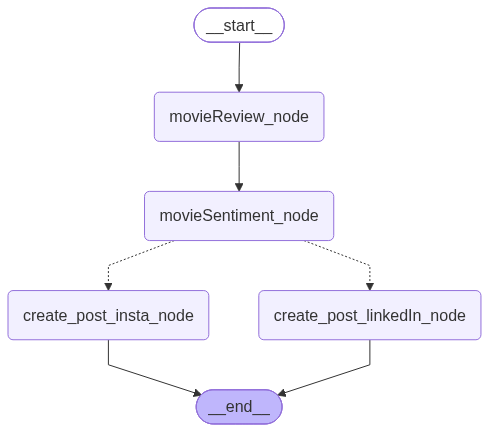

In [48]:
from IPython.display import Image, display

graph = graph.compile()

Image(graph.get_graph().draw_mermaid_png())

In [50]:
graph.invoke({
    "movieName": "JOHN CARTER",
    "movieReview" : "",
    "movieSentiment" : "",
    "moviePost" : ""
    })

{'movieName': 'JOHN CARTER',
 'movieReview': 'John Carter, based on Edgar Rice Burroughs’ Mars adventures, is a visually ambitious big-budget space opera that aims for old-fashioned pulp energy. The production design and large-scale action scenes are impressive and give the film a grand, adventurous vibe. Its weaknesses are pacing and dialogue, with heavy exposition and sometimes underdeveloped characters that can make the story feel bloated. If you enjoy bold, imaginative sci‑fi/fantasy spectacle, it’s worth a watch, though it may not click for everyone.',
 'movieSentiment': 'positive',
 'moviePost': 'Why you should watch John Carter (based on Edgar Rice Burroughs’ Mars adventures):\n\n- Visually ambitious, big-budget space opera with impressive production design and large-scale action that delivers a grand, adventurous vibe.\n- Strikes a classic, pulp-inspired tone that fans of imaginative sci-fi/fantasy spectacle will enjoy.\n- A strong showcase of world-building and spectacle, even